<div style="text-align:center; padding:18px 0 6px 0"></div>

<div style="text-align:center; color:#8b949e; font-size:12px; padding-bottom:8px">Copyright © QPerfect &middot; Released under the MIT License &middot; <a href="https://qperfect.io">qperfect.io</a></div>

---

# Classical TSP — algorithms and scaling

The Travelling Salesman Problem asks for the shortest closed tour visiting
each of $n$ cities exactly once. It is NP-hard in general, but classical
approaches stratify by problem size:

| Method | Practical $n$ | Complexity |
|---|---|---|
| Brute force | $\le 10$ | $O(n!)$ |
| Held–Karp DP | $\le 20$ | $O(n^2 2^n)$ |
| 2-opt local search | thousands | iterative |
| Simulated annealing | thousands | iterative |
| Concorde (state of the art) | ~85 000 historically | exact, branch-cut |

This notebook walks through the four solvers shipped in
`strasbourg_markets_demo.tsp`, plotting each tour and timing each call.


In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

from strasbourg_markets_demo import strasbourg as s, theme
from strasbourg_markets_demo.tsp import (
    TSPInstance, brute_force, held_karp, two_opt, simulated_annealing,
)

theme.apply()
RNG_SEED = 2024


## A small random instance

Eight cities in the unit square — small enough for brute force, large
enough to be non-trivial.

n = 8
distance matrix mean = 0.556


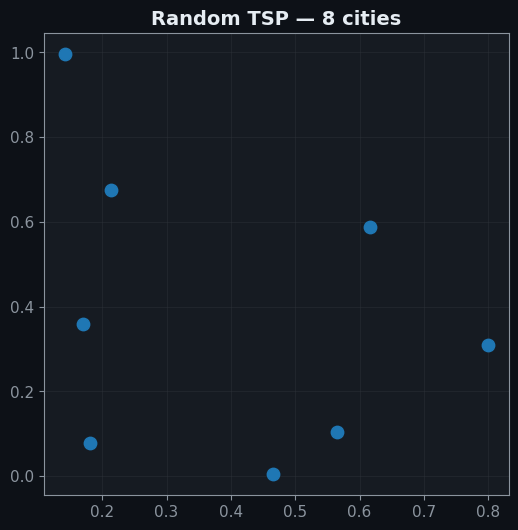

In [2]:
inst_small = TSPInstance.random(n=8, seed=RNG_SEED)
print(f"n = {inst_small.n}")
print(f"distance matrix mean = {inst_small.distances[np.triu_indices(inst_small.n, k=1)].mean():.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
inst_small.plot(ax=ax)
ax.set_title("Random TSP — 8 cities")
plt.show()


## Brute force enumeration

brute force      : length 2.6339    time 9.59 ms


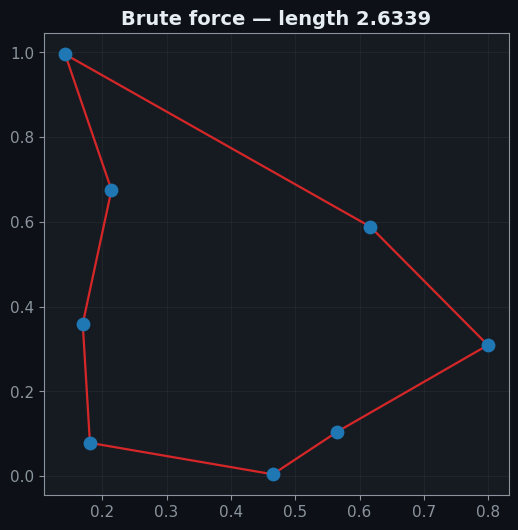

In [3]:
t0 = time.perf_counter()
tour_bf, length_bf = brute_force(inst_small)
t_bf = time.perf_counter() - t0
print(f"brute force      : length {length_bf:.4f}    time {t_bf*1e3:.2f} ms")

fig, ax = plt.subplots(figsize=(6, 6))
inst_small.plot(tour=tour_bf, ax=ax)
ax.set_title(f"Brute force — length {length_bf:.4f}")
plt.show()


## Held–Karp dynamic programming

held-karp        : length 2.6339    time 0.55 ms


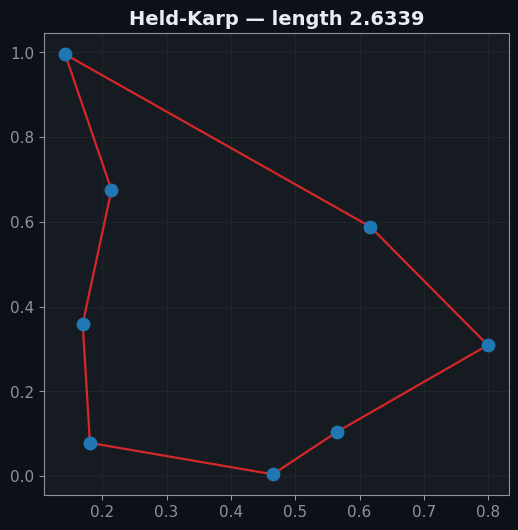

In [4]:
t0 = time.perf_counter()
tour_hk, length_hk = held_karp(inst_small)
t_hk = time.perf_counter() - t0
print(f"held-karp        : length {length_hk:.4f}    time {t_hk*1e3:.2f} ms")
assert np.isclose(length_hk, length_bf), "DP must match brute force on a small instance"

fig, ax = plt.subplots(figsize=(6, 6))
inst_small.plot(tour=tour_hk, ax=ax)
ax.set_title(f"Held-Karp — length {length_hk:.4f}")
plt.show()


## Heuristics: 2-opt and simulated annealing

For larger instances, exact solvers blow up. Heuristics return a tour
quickly with no optimality guarantee, but on Euclidean instances they
typically come within a few percent of the optimum.

2-opt            : length 3.1347    time 0.18 ms    gap 19.02 %
sim. annealing   : length 2.6339    time 30.75 ms    gap  0.00 %


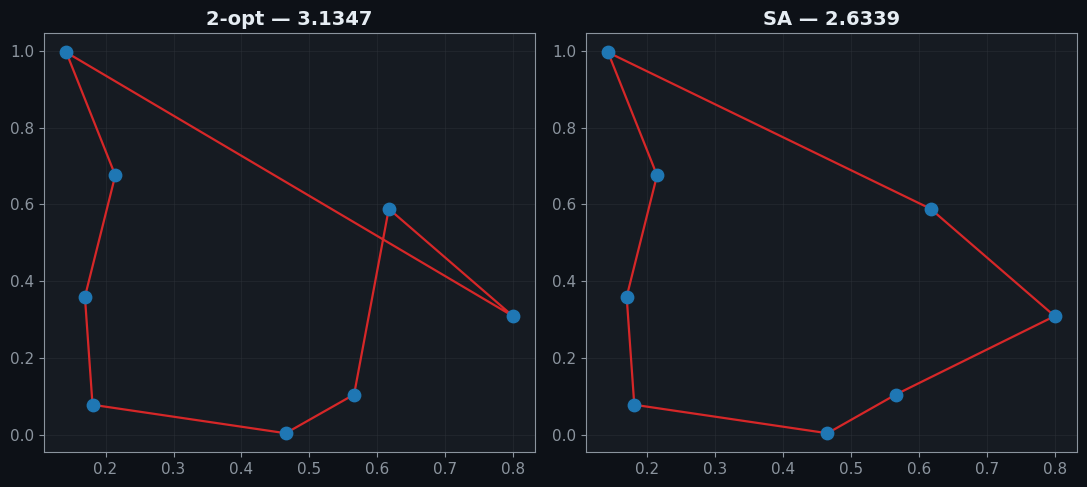

In [5]:
t0 = time.perf_counter()
tour_2o, length_2o = two_opt(inst_small)
t_2o = time.perf_counter() - t0

t0 = time.perf_counter()
tour_sa, length_sa = simulated_annealing(inst_small)
t_sa = time.perf_counter() - t0

print(f"2-opt            : length {length_2o:.4f}    time {t_2o*1e3:.2f} ms    gap {(length_2o/length_bf - 1)*100:5.2f} %")
print(f"sim. annealing   : length {length_sa:.4f}    time {t_sa*1e3:.2f} ms    gap {(length_sa/length_bf - 1)*100:5.2f} %")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
inst_small.plot(tour=tour_2o, ax=axes[0])
axes[0].set_title(f"2-opt — {length_2o:.4f}")
inst_small.plot(tour=tour_sa, ax=axes[1])
axes[1].set_title(f"SA — {length_sa:.4f}")
plt.tight_layout(); plt.show()


## Where brute force breaks

Brute force is $(n-1)!/2$ — at $n=15$ that's already 43 billion tours.
We skip it and compare DP against the heuristics.

In [6]:
inst_med = TSPInstance.random(n=15, seed=RNG_SEED)

results = {}
for name, fn in [("held_karp", held_karp), ("two_opt", two_opt),
                 ("simulated_annealing", simulated_annealing)]:
    t0 = time.perf_counter()
    tour, length = fn(inst_med)
    elapsed = time.perf_counter() - t0
    results[name] = (tour, length, elapsed)
    print(f"{name:24s} length {length:7.4f}    time {elapsed*1e3:7.1f} ms")

opt_len = results["held_karp"][1]
print()
print(f"2-opt gap to optimum: {(results['two_opt'][1]/opt_len - 1)*100:.2f} %")
print(f"SA    gap to optimum: {(results['simulated_annealing'][1]/opt_len - 1)*100:.2f} %")


held_karp                length  3.6752    time   214.3 ms
two_opt                  length  4.5077    time     0.2 ms
simulated_annealing      length  3.6752    time    28.5 ms

2-opt gap to optimum: 22.65 %
SA    gap to optimum: 0.00 %


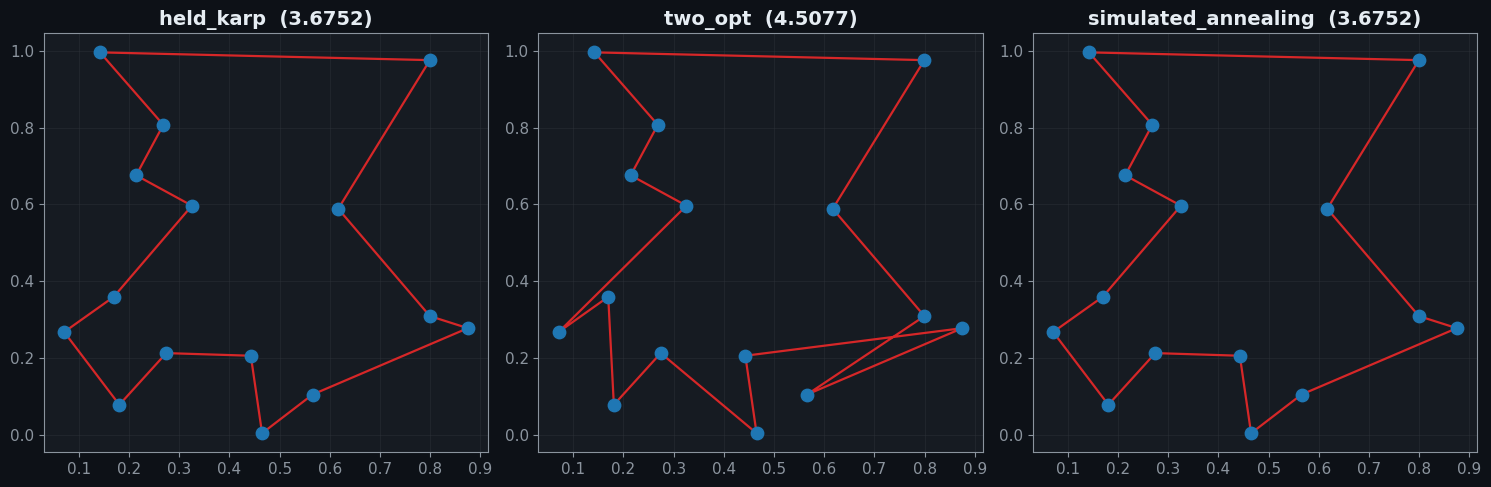

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, (tour, length, _)) in zip(axes, results.items()):
    inst_med.plot(tour=tour, ax=ax)
    ax.set_title(f"{name}  ({length:.4f})")
plt.tight_layout(); plt.show()


## Strasbourg Christmas markets

Five real Christmas-market sites — Place Kléber, Place Broglie, Cathédrale,
Place du Château, Place du Marché Gayot. The optimal tour is found in
microseconds and overlaid on an OSM basemap.

optimal tour: ['Place Kléber', 'Place Broglie', 'Place du Marché Gayot', 'Place du Château', 'Cathédrale Notre-Dame (marché)']
length      : 1366.49 m


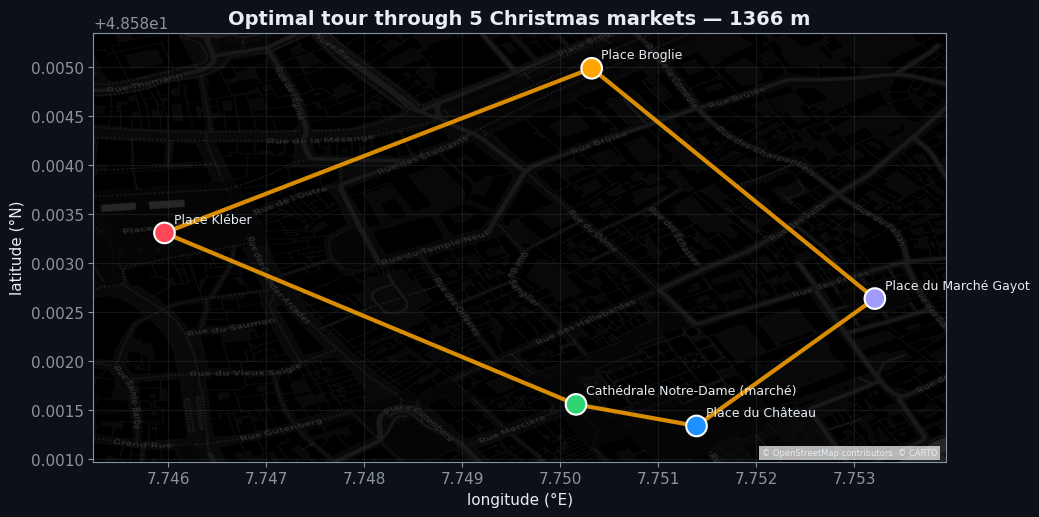

In [8]:
strasbourg_inst = TSPInstance.strasbourg_markets()
tour, length = brute_force(strasbourg_inst)
print(f"optimal tour: {[strasbourg_inst.names[i] for i in tour]}")
print(f"length      : {length:.2f} m")

# Build edges (closed tour) for the strasbourg plotter.
five = s.tsp_five()
ordered = [five[i] for i in tour]
edges = list(zip(ordered, ordered[1:] + [ordered[0]]))

fig, ax = plt.subplots(figsize=(11, 9))
s.plot(places=five, edges=edges, ax=ax,
       basemap=True, label="name",
       edge_color=theme.PALETTE["yellow"], edge_width=3.0,
       title=f"Optimal tour through 5 Christmas markets — {length:.0f} m")
plt.show()


## Summary

- Brute force: trivially correct, factorial scaling — abandons usefulness past $n \approx 12$.
- Held–Karp: pseudo-polynomial in $n$ via $2^n$ subset enumeration; useful up to ~20.
- 2-opt and SA: practical on real-world sizes; closeness to optimum depends on the instance and parameters.
- The Strasbourg-5 instance is *trivial* classically — its purpose in the demo is as a recognisable, geographically grounded warm-up for the QAOA section.



---

<div style="text-align:center; padding:18px 0 6px 0"></div>

<div style="text-align:center; color:#8b949e; font-size:12px; padding-bottom:8px">Copyright © QPerfect &middot; Released under the MIT License &middot; <a href="https://qperfect.io">qperfect.io</a></div>